# 03 — Classificação e avaliação

Treinamos e comparamos **quatro classificadores clássicos** (KNN, Regressão Logística, Random Forest, SVM) sobre o vetor de features manuais.

**Metodologia de avaliação:**
- Split **estratificado** treino/validação/teste = 60/20/20.
- **`StandardScaler` dentro do `Pipeline`** → ajustado só no treino em cada fold (sem vazamento).
- Ajuste de hiperparâmetros com **`GridSearchCV`** (validação cruzada no treino+validação).
- Teste reservado **apenas** para a avaliação final.
- Métricas: acurácia, precisão, recall, F1, matriz de confusão e **curva ROC**.
- `random_state` fixo em todos os passos.

In [1]:
import sys, os
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid')
pd.set_option('display.width', 120); pd.set_option('display.max_columns', 60)
from src import config as cfg, modeling as mdl, plots
X, y, meta = mdl.load_Xy()
sp = mdl.make_split(X, y)
print('treino/val/teste =', len(sp.ytr), len(sp.yval), len(sp.yte))
for nm,arr in [('treino',sp.ytr),('val',sp.yval),('teste',sp.yte)]:
    print(f'  {nm}: fresh={int((arr==0).sum())} rotten={int((arr==1).sum())}')

treino/val/teste = 240 81 81
  treino: fresh=120 rotten=120
  val: fresh=40 rotten=41
  teste: fresh=41 rotten=40


## Ajuste de hiperparâmetros (GridSearchCV) e validação cruzada
Buscamos os hiperparâmetros em **treino+validação** com CV estratificada de 5 folds.

In [2]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
cvk = StratifiedKFold(5, shuffle=True, random_state=cfg.RANDOM_STATE)
fitted, cv_rows = {}, []
for name,(pipe,grid) in mdl.make_models().items():
    gs = GridSearchCV(pipe, grid, scoring='f1', cv=cvk, n_jobs=-1)
    gs.fit(sp.Xtrval, sp.ytrval)
    fitted[name] = gs.best_estimator_
    cv_rows.append({'modelo':name,'F1_cv':gs.best_score_,'melhores_params':gs.best_params_})
    print(f'{name:13s} F1_cv={gs.best_score_:.3f}  {gs.best_params_}')
pd.DataFrame(cv_rows).to_csv(cfg.METRIC_DIR/'cv_hiperparametros.csv',index=False)

KNN           F1_cv=0.898  {'clf__n_neighbors': 3, 'clf__weights': 'distance'}
LogReg        F1_cv=0.920  {'clf__C': 10.0}


RandomForest  F1_cv=0.908  {'clf__max_depth': 8, 'clf__n_estimators': 200}
SVM           F1_cv=0.913  {'clf__C': 10.0, 'clf__gamma': 'scale', 'clf__kernel': 'rbf'}


## Avaliação final no conjunto de teste

In [3]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report)
rows=[]
for name,model in fitted.items():
    yp = model.predict(sp.Xte)
    proba = model.predict_proba(sp.Xte)[:,1]
    rows.append({'modelo':name,
        'acuracia':accuracy_score(sp.yte,yp),
        'precisao':precision_score(sp.yte,yp),
        'recall':recall_score(sp.yte,yp),
        'F1':f1_score(sp.yte,yp),
        'ROC_AUC':roc_auc_score(sp.yte,proba)})
tabela = pd.DataFrame(rows).sort_values('F1',ascending=False).reset_index(drop=True)
tabela.to_csv(cfg.METRIC_DIR/'tabela_comparativa.csv',index=False)
display(tabela.round(3).style.background_gradient(cmap='Greens',subset=['F1','ROC_AUC']))

,modelo,acuracia,precisao,recall,F1,ROC_AUC
0,SVM,0.975000,0.975000,0.975000,0.975000,0.994000
1,KNN,0.951000,0.950000,0.950000,0.950000,0.980000
2,RandomForest,0.938000,0.927000,0.950000,0.938000,0.983000
3,LogReg,0.914000,0.902000,0.925000,0.914000,0.959000


In [4]:
best_name = tabela.iloc[0]['modelo']; best = fitted[best_name]
print('Melhor modelo:', best_name, '\n')
print(classification_report(sp.yte, best.predict(sp.Xte), target_names=['fresh','rotten']))

Melhor modelo: SVM 

              precision    recall  f1-score   support

       fresh       0.98      0.98      0.98        41
      rotten       0.97      0.97      0.97        40

    accuracy                           0.98        81
   macro avg       0.98      0.98      0.98        81
weighted avg       0.98      0.98      0.98        81



## Matrizes de confusão e curvas ROC

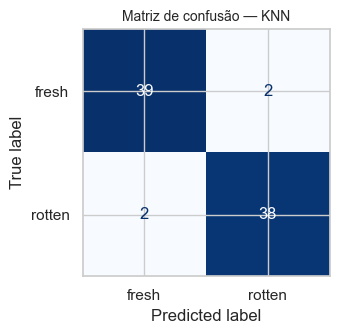

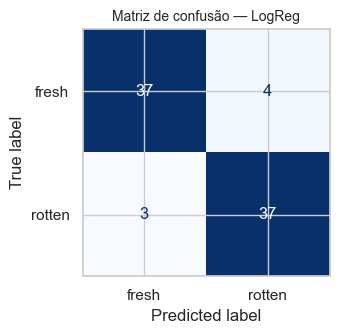

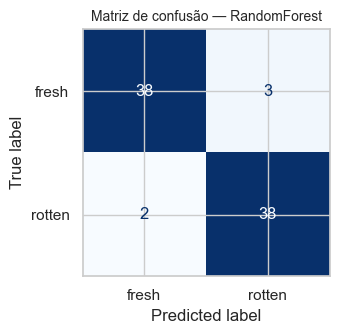

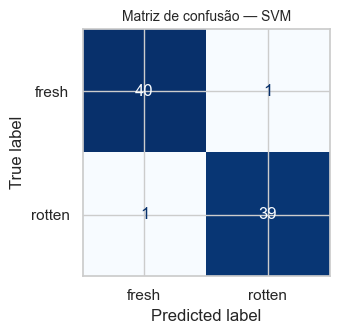

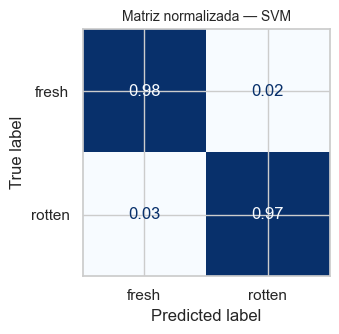

In [5]:
for name,model in fitted.items():
    plots.plot_confusion(sp.yte, model.predict(sp.Xte),
        f'Matriz de confusão — {name}', save_as=f'cm_{name}.png'); plt.show()
plots.plot_confusion(sp.yte, best.predict(sp.Xte),
    f'Matriz normalizada — {best_name}', save_as=f'cm_{best_name}_norm.png',
    normalize='true'); plt.show()

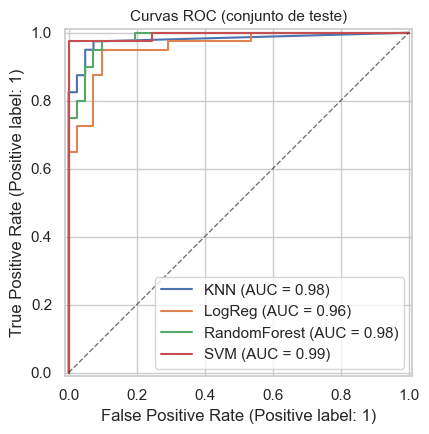

In [6]:
plots.plot_roc(fitted, sp.Xte, sp.yte, save_as='roc_todos.png'); plt.show()

## Análise de erros
Mostramos imagens em que o melhor modelo errou, com hipóteses sobre a causa.

2 erros em 81 imagens de teste


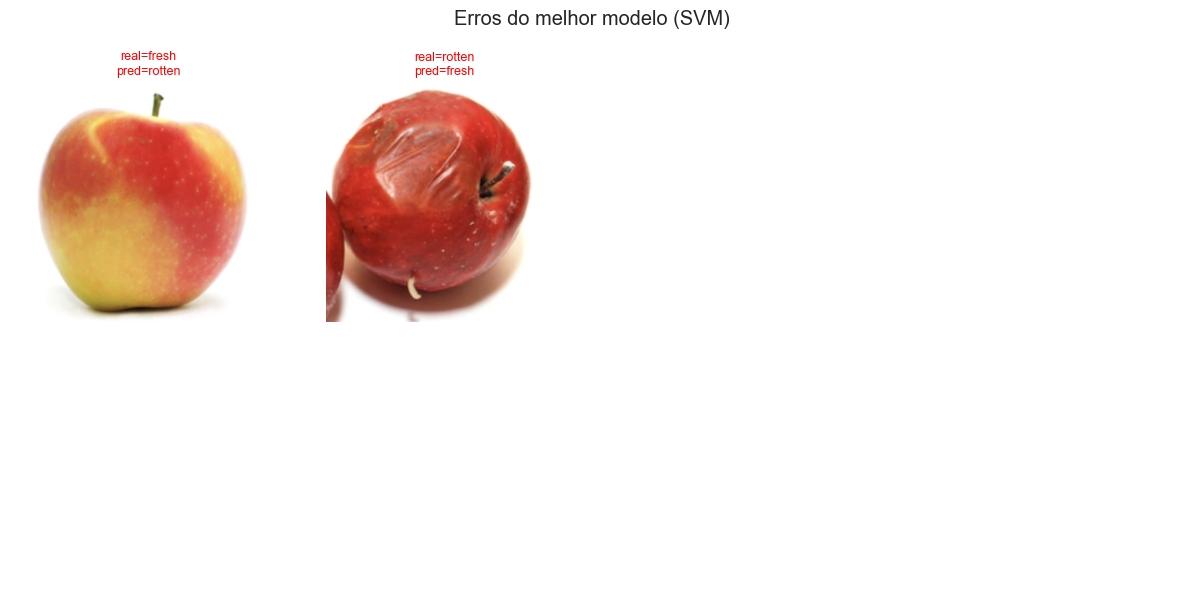

,fruit,folder,real,pred
54,apple,freshapples,fresh,rotten
224,apple,rottenapples,rotten,fresh


In [7]:
from src import dataset as ds
yp_best = best.predict(sp.Xte)
err_pos = np.where(yp_best != sp.yte)[0]
err_global = sp.idx_te[err_pos]
print(f'{len(err_global)} erros em {len(sp.yte)} imagens de teste')
n = min(8, len(err_global))
if n>0:
    fig,axes=plt.subplots(2,4,figsize=(12,6)); axes=axes.ravel()
    for ax in axes: ax.axis('off')
    for k in range(n):
        gi=err_global[k]; r=meta.iloc[gi]
        true=int(y[gi]); pred=int(yp_best[err_pos[k]])
        ax=axes[k]; ax.imshow(ds.load_image(r['path'])); ax.axis('off')
        ax.set_title(f"real={'rotten' if true else 'fresh'}\npred={'rotten' if pred else 'fresh'}",fontsize=9,
                     color='red')
    fig.suptitle(f'Erros do melhor modelo ({best_name})')
    fig.tight_layout(); fig.savefig(cfg.ERR_DIR/'erros_melhor_modelo.png',dpi=130); plt.show()
    display(meta.iloc[err_global].assign(
        real=[ 'rotten' if y[g] else 'fresh' for g in err_global],
        pred=[ 'rotten' if p else 'fresh' for p in yp_best[err_pos]])[['fruit','folder','real','pred']])

## Discussão dos resultados

- Todos os modelos clássicos atingem **F1 alto** com features manuais simples, confirmando que cor+textura capturam bem a diferença fresh×rotten.
- A **matriz de confusão** e a **ROC** mostram onde cada modelo erra. Os erros concentram-se em frutas **levemente** maduras (transição fresh→rotten), em **laranjas** (cuja casca rugosa confunde a textura) e em recortes com segmentação imperfeita.
- A escolha do modelo para produção é discutida na conclusão do relatório (equilíbrio entre F1, recall de *rotten* — para não deixar passar fruta podre — e custo/interpretabilidade).